In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv("heart.csv")

In [3]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


# EDA

In [5]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [7]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


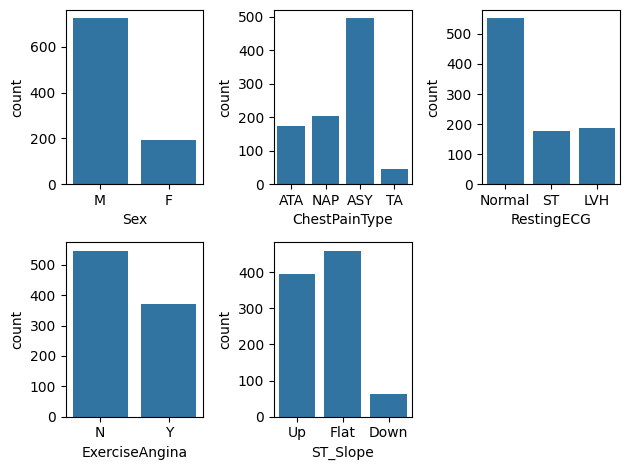

In [8]:
cat = df.select_dtypes(include="object")
n =1
for cnt in cat :
    plt.subplot(2,3, n)
    sns.countplot(x = df[cnt])
    n +=1
    plt.tight_layout()

<Axes: xlabel='HeartDisease'>

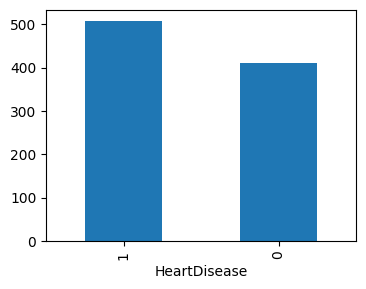

In [9]:
plt.figure(figsize=(4,3))
df["HeartDisease"].value_counts().plot(kind="bar")

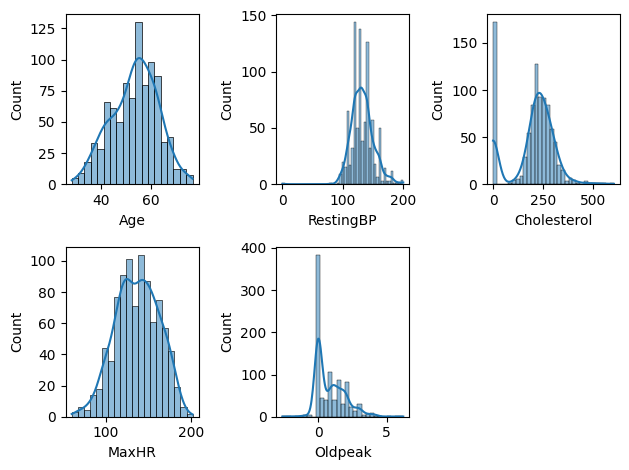

In [10]:
num1 = df.loc[:,['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']]
n =1
for i in num1:
    plt.subplot(2,3,n)
    sns.histplot(df[i], kde=True)
    n+=1
    plt.tight_layout()

In [11]:
df["Cholesterol"].value_counts()

Cholesterol
0      172
254     11
223     10
220     10
230      9
      ... 
392      1
316      1
153      1
466      1
131      1
Name: count, Length: 222, dtype: int64

 a human body cannot have zero cholesterol because this waxy substance is vital for building cell walls, making hormones, and producing vitamin D

In [12]:
mean = df.loc[df["Cholesterol"]!=0,"Cholesterol"].mean()
df["Cholesterol"] = df["Cholesterol"].replace(0,mean)

In [13]:
df['Cholesterol'].value_counts()

Cholesterol
244.635389    172
254.000000     11
223.000000     10
220.000000     10
230.000000      9
             ... 
392.000000      1
316.000000      1
153.000000      1
466.000000      1
131.000000      1
Name: count, Length: 222, dtype: int64

<Axes: xlabel='Cholesterol', ylabel='Count'>

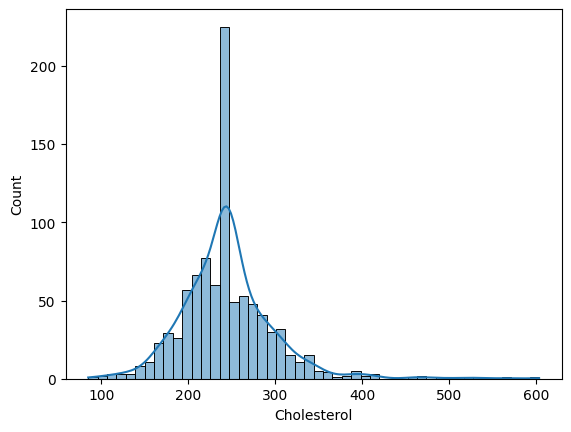

In [14]:
sns.histplot(df["Cholesterol"],kde=True)

In [15]:
df.loc[df["RestingBP"]==0,"RestingBP"]

449    0
Name: RestingBP, dtype: int64

No, a resting blood pressure reading cannot be zero while a person is alive; a reading of zero means there is no blood circulation or heart function,

In [16]:
meann = df.loc[df["RestingBP"]!=0,"RestingBP"].mean()
df["RestingBP"] = df["RestingBP"].replace(0,meann)

In [17]:
df.loc[df["RestingBP"]==0,"RestingBP"]

Series([], Name: RestingBP, dtype: float64)

<Axes: xlabel='RestingBP', ylabel='Count'>

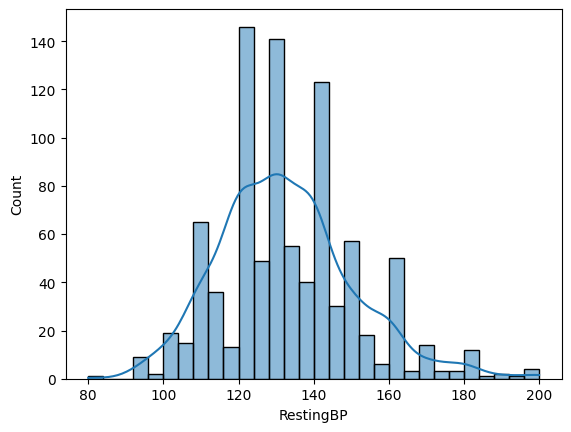

In [18]:
sns.histplot(df["RestingBP"],kde=True)

In [19]:
df["Oldpeak"].value_counts()

Oldpeak
 0.0    368
 1.0     86
 2.0     76
 1.5     53
 3.0     28
 1.2     26
 0.2     22
 0.5     19
 1.4     18
 1.8     17
 2.5     16
 0.8     16
 1.6     16
 0.1     14
 0.6     14
 0.4     11
 0.3     11
 4.0      8
 0.7      7
 2.8      7
 1.9      7
 1.3      7
 2.6      7
 1.1      7
 1.7      6
 2.2      5
 0.9      4
 2.4      4
 3.6      4
 3.4      3
 4.2      2
 3.5      2
-0.5      2
 2.3      2
 3.2      2
 2.1      2
-1.0      2
-0.1      2
 5.6      1
 2.9      1
 6.2      1
 3.8      1
-1.5      1
 3.1      1
-2.0      1
 3.7      1
-0.8      1
-0.7      1
-1.1      1
-2.6      1
-0.9      1
 5.0      1
 4.4      1
Name: count, dtype: int64

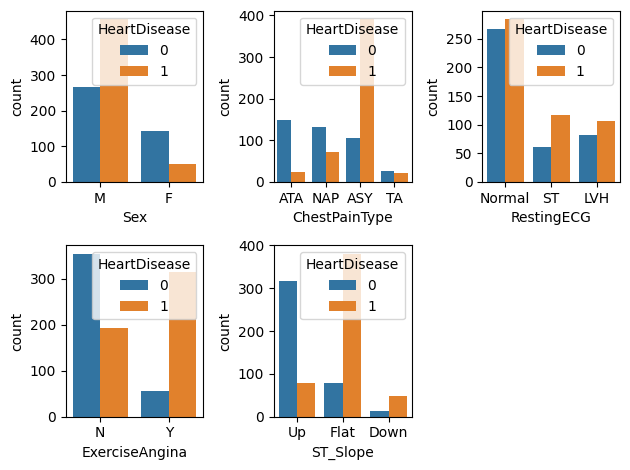

In [20]:
#cheacking a pribality of geting  a hrart desies
cat = df.select_dtypes(include="object")
n =1
for cnt in cat :
    plt.subplot(2,3, n)
    sns.countplot(x = df[cnt],hue = df['HeartDisease'])
    n +=1
    plt.tight_layout()


<Axes: xlabel='HeartDisease', ylabel='Cholesterol'>

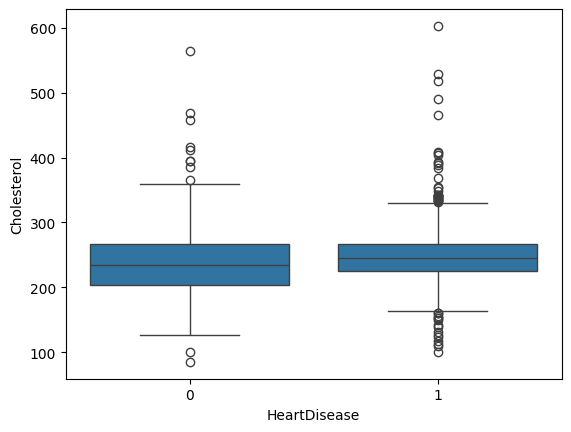

In [21]:
sns.boxplot(x = 'HeartDisease', y = 'Cholesterol',data = df)

<Axes: xlabel='HeartDisease', ylabel='Age'>

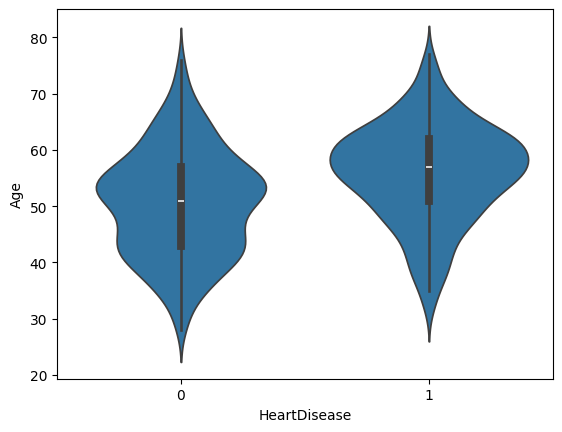

In [22]:
sns.violinplot(x='HeartDisease', y='Age', data=df)

<Axes: >

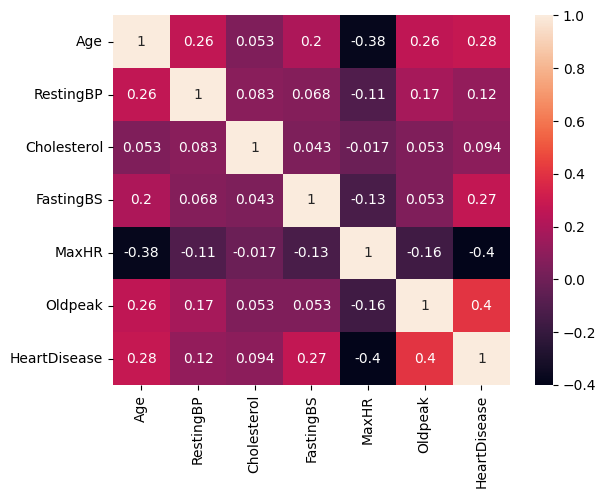

In [23]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

# Data perprocessing and cleaning

In [24]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


In [38]:
from sklearn.preprocessing import StandardScaler
# Copy dataframe
df_encoded = df.copy()

# Ordinal encoding via map
df_encoded["Sex"] = df_encoded["Sex"].map({"F": 0, "M": 1})
df_encoded["ST_Slope"] = df_encoded["ST_Slope"].map(
    {"Down": 0, "Flat": 1, "Up": 2}
)

# One-hot encoding via get_dummies
df_encoded = pd.get_dummies(
    df_encoded,
    columns=["ChestPainType", "RestingECG", "ExerciseAngina"],
    drop_first=True,
    dtype=int,
)
numeric_cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
scaleing = StandardScaler()
df_encoded[numeric_cols] = scaleing.fit_transform(df_encoded[numeric_cols])

df_encoded.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,ST_Slope,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y
0,-1.433140,1,0.414853,0.832529,0,1.382928,-0.832432,2,0,1,0,0,1,0,0
1,-0.478484,0,1.527192,-1.212922,0,0.754157,0.105664,1,1,0,1,0,1,0,0
2,-1.751359,1,-0.141317,0.719935,0,-1.525138,-0.832432,2,0,1,0,0,0,1,0
3,-0.584556,0,0.303619,-0.574892,0,-1.132156,0.574711,1,1,0,0,0,1,0,1
4,0.051881,1,0.971022,-0.931438,0,-0.581981,-0.832432,2,0,0,1,0,1,0,0


In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# 1. Separate features and target
X = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"]

# 2. Define feature categories
one_hot_cols = ["ChestPainType", "RestingECG", "ExerciseAngina"]
ordinal_cols = ["Sex", "ST_Slope","FastingBS"]
numeric_cols = ["Age", "RestingBP", "Cholesterol",  "MaxHR", "Oldpeak"]

# 3. Define transformers for each data type
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

ordinal_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder()),
    ]
)

# 4. Combine into a ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, one_hot_cols),
        ("ord", ordinal_transformer, ordinal_cols),
    ]
)

# 5. Build the full modeling pipeline
model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(random_state=42)),
    ]
)

# 6. Train and evaluate
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
model_pipeline.fit(X_train, y_train)

print(f"Test Accuracy: {model_pipeline.score(X_test, y_test):.4f}")

Test Accuracy: 0.8641


In [31]:
df["FastingBS"].value_counts()

FastingBS
0    704
1    214
Name: count, dtype: int64